In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    finalNumber: int

In [4]:
def adder(state: AgentState) -> AgentState:
    """This node adds 2 numbers"""
    state['finalNumber'] = state['number1'] + state['number2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts 2 numbers"""
    state['finalNumber'] = state['number1'] - state['number2']
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""
    if state['operation'] == '+':
        return 'addition_operation'
    elif state['operation'] == '-':
        return 'subtractor_operation'

In [9]:
graph = StateGraph(AgentState)

graph.add_node('add_node', adder)
graph.add_node('subtract_node', subtractor)
graph.add_node('router', lambda state:state) # passthrough function

graph.add_edge(START, 'router')

graph.add_conditional_edges(
    'router',
    decide_next_node,
    {   
        # Edge: Node
        'addition_operation': 'add_node',
        'subtractor_operation': 'subtract_node'
    }
)

graph.add_edge('add_node', END)
graph.add_edge('subtract_node', END)

app = graph.compile()

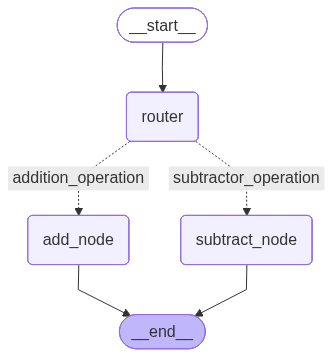

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
initial_state_1 = AgentState(number1 = 10, number2 = 6, operation = "-")
print(app.invoke(initial_state_1))

{'number1': 10, 'number2': 6, 'operation': '-', 'finalNumber': 4}


In [13]:
initial_state_2 = AgentState(number1 = 10, number2 = 6, operation = "+")
print(app.invoke(initial_state_2))

{'number1': 10, 'number2': 6, 'operation': '+', 'finalNumber': 16}
